# Exploration Policies Deep Dive: Thompson vs UCB vs Epsilon-Greedy

This notebook compares the three exploration policies in depth, examines how their hyperparameters affect the exploration-exploitation trade-off, and shows how to integrate them with causal estimators in a full pipeline.

In [1]:
import random
import math
import matplotlib
import matplotlib.pyplot as plt

from onlinecml.policy import EpsilonGreedy, ThompsonSampling, GaussianThompsonSampling, UCB

## 1. Epsilon schedule comparison

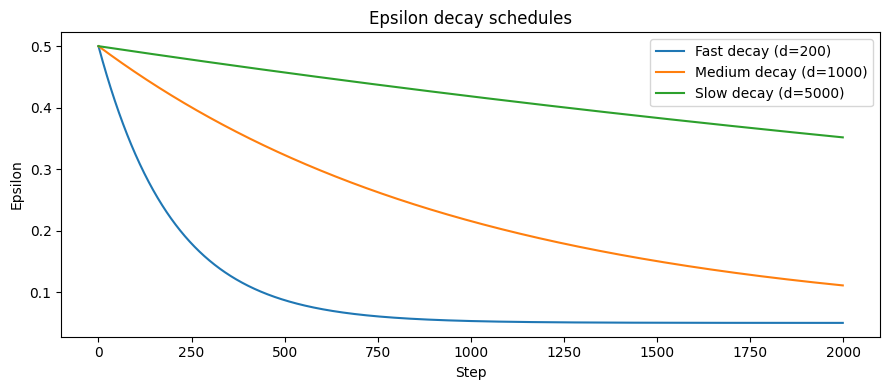

In [2]:
steps = list(range(2000))

schedules = {
    "Fast decay (d=200)": EpsilonGreedy(eps_start=0.5, eps_end=0.05, decay=200, seed=0),
    "Medium decay (d=1000)": EpsilonGreedy(eps_start=0.5, eps_end=0.05, decay=1000, seed=0),
    "Slow decay (d=5000)": EpsilonGreedy(eps_start=0.5, eps_end=0.05, decay=5000, seed=0),
}

fig, ax = plt.subplots(figsize=(9, 4))
for name, policy in schedules.items():
    eps_vals = [policy.current_epsilon(s) for s in steps]
    ax.plot(steps, eps_vals, label=name)
ax.set_xlabel("Step")
ax.set_ylabel("Epsilon")
ax.set_title("Epsilon decay schedules")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/epsilon_schedules.png", dpi=100)

## 2. UCB confidence parameter effect

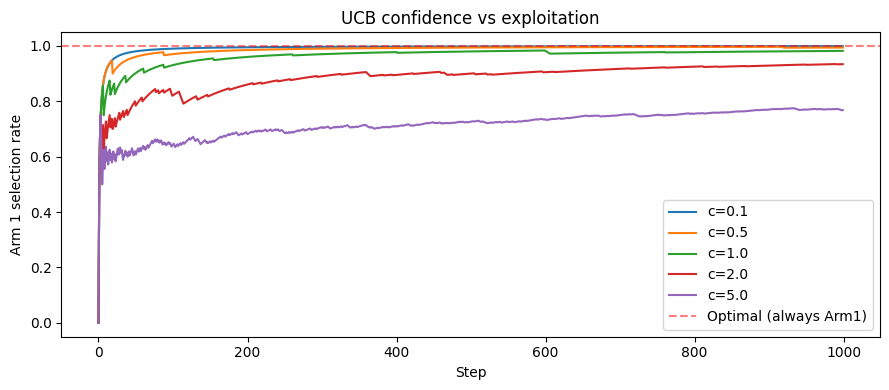

In [3]:
def run_bandit(policy, n=1000, arm_rewards=(0.3, 0.7), seed=0):
    rng = random.Random(seed)
    arm1_rate = []
    total = 0
    for step in range(n):
        t, _ = policy.choose(0.0, step)
        r = 1.0 if rng.random() < arm_rewards[t] else 0.0
        policy.update(r)
        total += int(t == 1)
        arm1_rate.append(total / (step + 1))
    return arm1_rate

confs = [0.1, 0.5, 1.0, 2.0, 5.0]
fig, ax = plt.subplots(figsize=(9, 4))
for c in confs:
    rates = run_bandit(UCB(confidence=c), n=1000)
    ax.plot(rates, label=f"c={c}")
ax.axhline(1.0, color="red", linestyle="--", alpha=0.5, label="Optimal (always Arm1)")
ax.set_xlabel("Step")
ax.set_ylabel("Arm 1 selection rate")
ax.set_title("UCB confidence vs exploitation")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/ucb_confidence.png", dpi=100)

## 3. Thompson Sampling: prior sensitivity

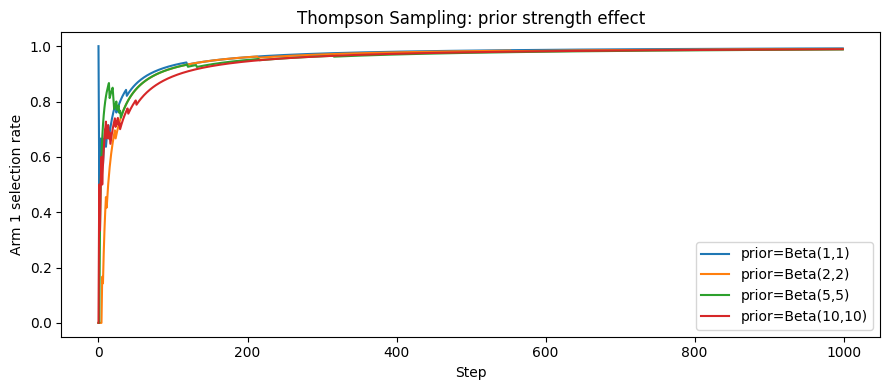

In [4]:
priors = [(1.0, 1.0), (2.0, 2.0), (5.0, 5.0), (10.0, 10.0)]
fig, ax = plt.subplots(figsize=(9, 4))
for alpha_p, beta_p in priors:
    policy = ThompsonSampling(alpha_prior=alpha_p, beta_prior=beta_p, seed=0)
    rates = run_bandit(policy, n=1000)
    ax.plot(rates, label=f"prior=Beta({alpha_p:.0f},{beta_p:.0f})")
ax.set_xlabel("Step")
ax.set_ylabel("Arm 1 selection rate")
ax.set_title("Thompson Sampling: prior strength effect")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/thompson_priors.png", dpi=100)

## 4. Policy + causal estimator pipeline

In [5]:
from river.linear_model import LinearRegression
from onlinecml.datasets import LinearCausalStream
from onlinecml.metalearners import OnlineTLearner

policies = {
    "EpsilonGreedy": EpsilonGreedy(seed=0),
    "Thompson": ThompsonSampling(seed=0),
    "UCB": UCB(confidence=1.0),
}

print(f"{'Policy':>14} | {'ATE est':>8} | {'n_seen':>7}")
print("-" * 35)
for name, policy in policies.items():
    learner = OnlineTLearner(
        treated_model=LinearRegression(),
        control_model=LinearRegression(),
    )
    for step, (x, w_true, y, tau) in enumerate(LinearCausalStream(n=500, true_ate=2.0, seed=5)):
        cate = learner.predict_one(x)
        t, prop = policy.choose(cate, step)
        policy.update(float(y > 0))
        learner.learn_one(x, w_true, y)  # use true RCT treatment for the causal model
    print(f"{name:>14} | {learner.predict_ate():>8.3f} | {learner.n_seen:>7}")

        Policy |  ATE est |  n_seen
-----------------------------------
 EpsilonGreedy |    1.753 |     500
      Thompson |    1.753 |     500
           UCB |    1.753 |     500


/tmp/ipykernel_86750/2508220338.py:19: UserWarning: treated_model has not seen any data yet; CATE estimate may be biased.
  cate = learner.predict_one(x)
/tmp/ipykernel_86750/2508220338.py:19: UserWarning: control_model has not seen any data yet; CATE estimate may be biased.
  cate = learner.predict_one(x)
